# CESM2 SMYLE, lead months 1-3

247 quarterly initializations, 1958-2019. Detrended within each init month, so the seasonal cycle goes with the trend.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import infomeasure
from joblib import Parallel, delayed

sys.path.insert(0, "../scripts")
import snp_path  # noqa: F401  # scripts/ subfolders -> sys.path
import smyle_handles as S

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica Neue']})
rc('text', usetex=False)

F, G = S.F, S.G                  # (N, J, lat, lon) members, (J, lat, lon) obs, Pa
s = F.mean(axis=0)               # (J, lat, lon)    ensemble mean
lats, lons, W = S.lats, S.lons, S.W
YEAR, MONTH, TIME = S.YEAR, S.MONTH, S.TIME

print("%d members x %d initializations (quarterly %d-%d), lead months 1-%d, N48 %d x %d"
      % (S.N, S.J, YEAR[0], YEAR[-1], S.NLEAD, len(lats), len(lons)))
for _n, _a in [("F", F), ("G", G), ("s", s)]:
    print("%-4s %s" % (_n, _a.shape))

20 members x 247 initializations (quarterly 1958-2019), lead months 1-3, N48 73 x 96
F    (20, 247, 73, 96)
G    (247, 73, 96)
s    (247, 73, 96)


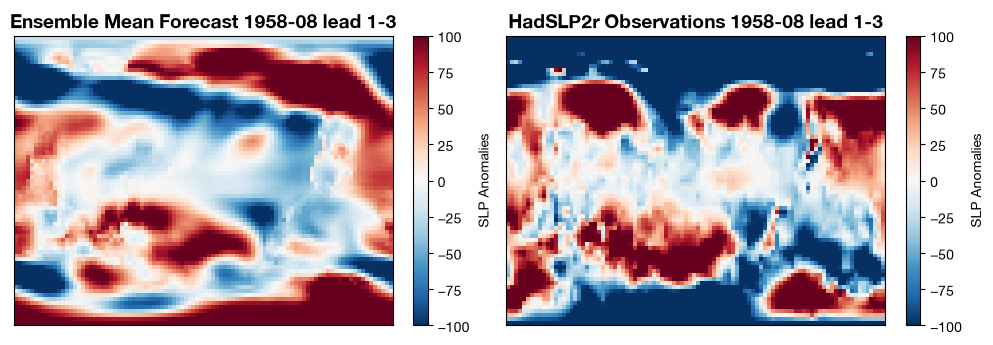

In [2]:
# See snapshots for comparison
YR_IDX = 2

COLOR_SCALE = 100

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(s[YR_IDX], clim=[-COLOR_SCALE, COLOR_SCALE], cmap='RdBu_r')
im1 = axs[1].imshow(G[YR_IDX], clim=[-COLOR_SCALE, COLOR_SCALE], cmap='RdBu_r')
fig.colorbar(im1, ax=axs[1], fraction=0.035, label='SLP Anomalies')
fig.colorbar(im1, ax=axs[0], fraction=0.035, label='SLP Anomalies')

for i in range(2):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
_lbl = f'{YEAR[YR_IDX]}-{MONTH[YR_IDX]:02d}'
axs[0].set_title(f'Ensemble Mean Forecast {_lbl} lead 1-3', fontweight=700, fontsize=14)
axs[1].set_title(f'HadSLP2r Observations {_lbl} lead 1-3', fontweight=700, fontsize=14)
plt.tight_layout()

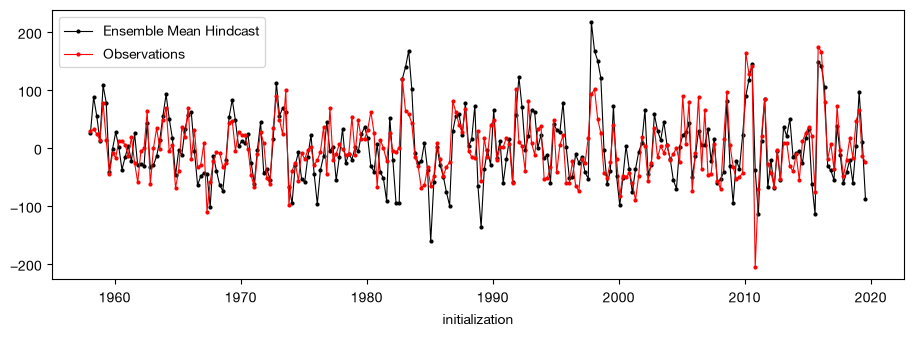

In [3]:
# Build a box and area-average within it
a1, a2 = 40, 50
b1, b2 = 30, 50

s_t = np.mean(s[:, a1:a2, b1:b2], axis=(1, 2))
G_t = np.mean(G[:, a1:a2, b1:b2], axis=(1, 2))

plt.figure(figsize=(11, 3.5))
plt.plot(TIME, s_t, 'k.-', lw=0.8, ms=4)
plt.plot(TIME, G_t, 'r.-', lw=0.8, ms=4)
plt.legend(['Ensemble Mean Hindcast', 'Observations'])
plt.xlabel('initialization');

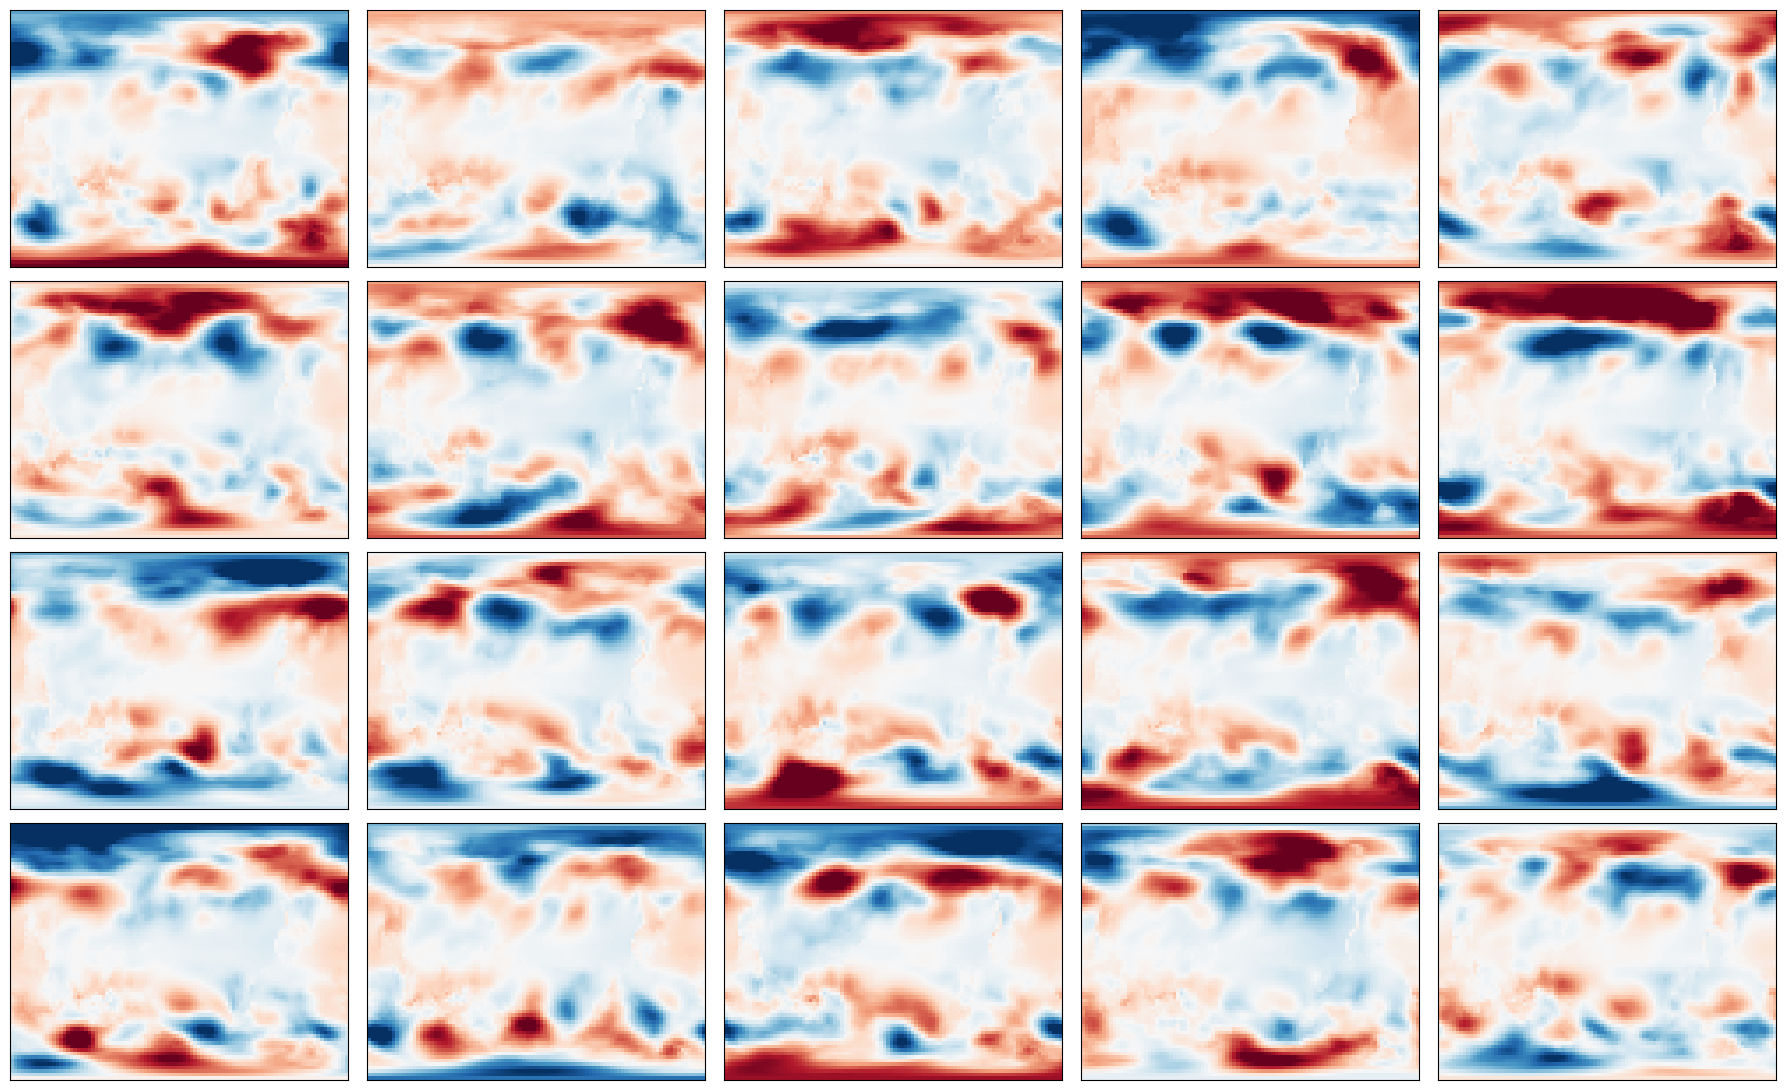

In [4]:
YR_IDX = 2

fig, axs = plt.subplots(4, 5, figsize=(18, 11))
axs = axs.flatten()

for i in range(len(axs)):
    if i < F.shape[0]:
        axs[i].imshow(F[i, YR_IDX], clim=[-500, 500], cmap='RdBu_r')
    else:
        for sp in axs[i].spines.values():
            sp.set_visible(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.tight_layout()

In [5]:
def pearson_coeff(s, G):
    # NOTE: axis=0 on the numerator. Without it np.mean collapses to a scalar and
    # the map becomes one global covariance over per-cell std -- it correlated
    # +0.003 with this and could never go negative.
    num = np.mean((s - np.mean(s, axis=0)) * (G - np.mean(G, axis=0)), axis=0)
    den = np.std(s, axis=0) * np.std(G, axis=0)
    return num / den


def ensemble_SNR(F):
    s = np.mean(F, axis=0)
    noise = np.mean(np.std(F, axis=1), axis=0)
    return np.std(s, axis=0) / noise

Text(0.5, 1.0, '$\\rho=\\rho_o/\\rho_m$')

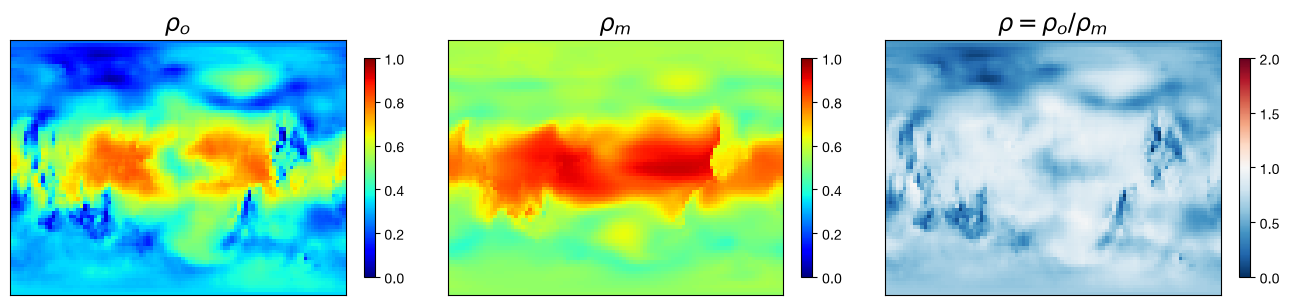

In [15]:
rho_o = pearson_coeff(s, G)
rho_m = ensemble_SNR(F)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
im0 = axs[0].imshow(rho_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(rho_m, cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(rho_o / rho_m, cmap='RdBu_r', vmin=0, vmax=2)
fig.colorbar(im0, ax=axs[0], fraction=0.03)
fig.colorbar(im1, ax=axs[1], fraction=0.03)
fig.colorbar(im2, ax=axs[2], fraction=0.03)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])

axs[0].set_title('$\\rho_o$', fontsize=17)
axs[1].set_title('$\\rho_m$', fontsize=17)
axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

In [7]:
def calc_MI_sG(s, G, k=4, n_jobs=-1):
    """I(s ; g) per grid cell. (J, m, n) x (J, m, n) -> (m, n)."""
    _, m, n = s.shape
    s2 = np.ascontiguousarray(s.reshape(s.shape[0], -1))
    G2 = np.ascontiguousarray(G.reshape(G.shape[0], -1))

    def calc_point(p):
        return infomeasure.mutual_information(s2[:, p], G2[:, p],
                                              approach='metric', k=k)

    out = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(calc_point)(p) for p in range(m * n))
    return np.asarray(out).reshape(m, n)


def calc_MI_sF(F, k=4, n_jobs=-1):
    """Leave-one-out I(s_-n ; f_n), averaged over members. F is (N, J, m, n)."""
    N, T, m, n = F.shape
    F2 = np.ascontiguousarray(F.reshape(N, T, -1))
    Fsum = F2.sum(axis=0)                                  # (T, space)

    def calc_point(p):
        fp = F2[:, :, p]                                   # (N, T)
        total = Fsum[:, p]                                 # (T,)
        vals = np.empty(N)
        for member in range(N):
            x = fp[member]
            loo_s = (total - x) / (N - 1)                  # mean of the OTHER N-1
            vals[member] = infomeasure.mutual_information(loo_s, x,
                                                          approach="metric", k=k)
        return vals.mean()

    out = Parallel(n_jobs=n_jobs, backend="loky", batch_size="auto")(
        delayed(calc_point)(p) for p in range(m * n))
    return np.asarray(out).reshape(m, n)

In [8]:
MIsG_k1 = calc_MI_sG(s, G, k=1)
MIsG_k3 = calc_MI_sG(s, G, k=3)
MIsG_k4 = calc_MI_sG(s, G, k=4)

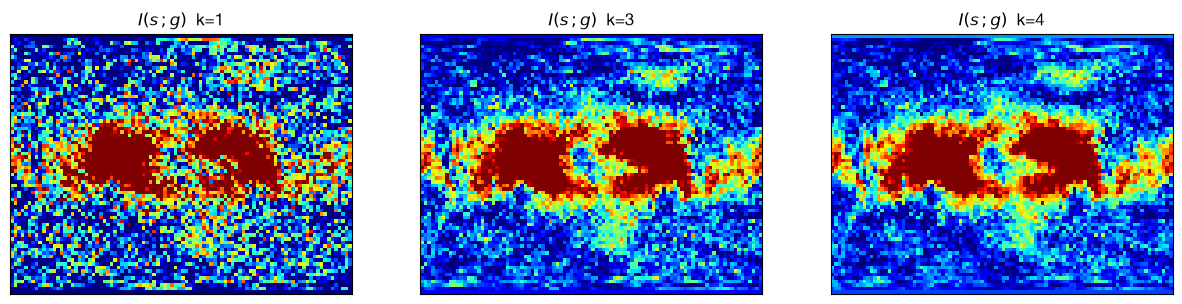

In [9]:
VMIN, VMAX = 0, 0.3
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, a, t in zip(axs, (MIsG_k1, MIsG_k3, MIsG_k4), ('k=1', 'k=3', 'k=4')):
    ax.imshow(a, vmin=VMIN, vmax=VMAX, cmap='jet')
    ax.set_title(f'$I(s\\,;g)$  {t}')
    ax.set_xticks([])
    ax.set_yticks([])

In [10]:
MIsF_k3 = calc_MI_sF(F, k=3)
MIsF_k4 = calc_MI_sF(F, k=4)
MIsF_k5 = calc_MI_sF(F, k=5)

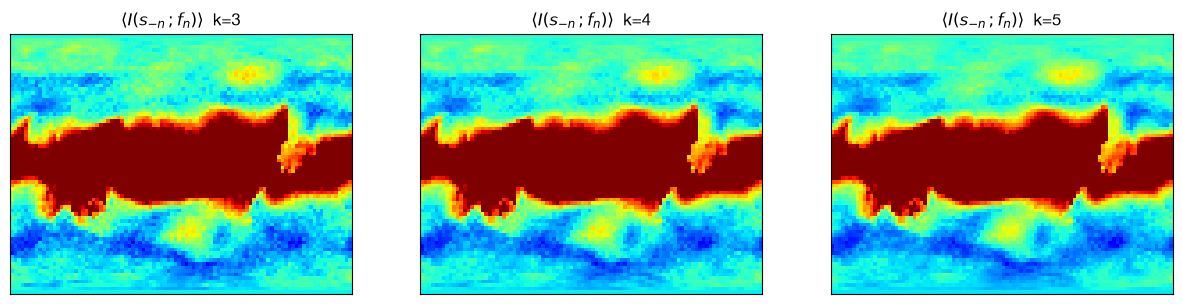

In [11]:
VMIN, VMAX = 0, 0.3
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, a, t in zip(axs, (MIsF_k3, MIsF_k4, MIsF_k5), ('k=3', 'k=4', 'k=5')):
    ax.imshow(a, vmin=VMIN, vmax=VMAX, cmap='jet')
    ax.set_title(f'$\\langle I(s_{{-n}}\\,;f_n)\\rangle$  {t}')
    ax.set_xticks([])
    ax.set_yticks([])

In [12]:
lam_of = lambda I: np.sqrt(1 - np.exp(-2 * np.maximum(I, 0)) + 1e-6)

lam_o = lam_of(MIsG_k4)
lam_m = lam_of(MIsF_k4)

Text(0.5, 1.0, '$\\lambda=\\lambda_o/\\lambda_m$')

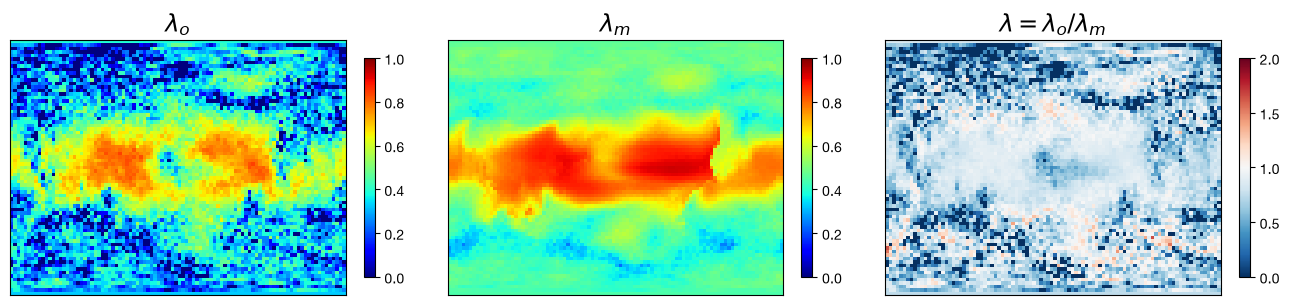

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
im0 = axs[0].imshow(lam_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(lam_m, cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(lam_o / lam_m, cmap='RdBu_r', vmin=0, vmax=2)
fig.colorbar(im0, ax=axs[0], fraction=0.03)
fig.colorbar(im1, ax=axs[1], fraction=0.03)
fig.colorbar(im2, ax=axs[2], fraction=0.03)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])

axs[0].set_title('$\\lambda_o$', fontsize=17)
axs[1].set_title('$\\lambda_m$', fontsize=17)
axs[2].set_title('$\\lambda=\\lambda_o/\\lambda_m$', fontsize=17)

## scratch